# Model Comparison and Evaluation
**Lecture Activity 3 - IT325 Machine Learning | John Lemar L. Gonzales BSIT3R15**

---


## 1. Setup and Imports

In [1]:
# Import the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("All libraries loaded!")


All libraries loaded!


## 2. Load and Prepare the Dataset

In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Lemar\GithubRepositories\student-depression-detector\notebooks\Student Depression Dataset.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
# Encode text/categorical columns into numbers so the models can read them
df_model = df.copy()
le = LabelEncoder()

# Find all text columns and encode them
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Drop rows with any missing values
df_model = df_model.dropna()

print("Columns encoded:", list(cat_cols))
print("Remaining rows after dropna:", len(df_model))


Columns encoded: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
Remaining rows after dropna: 27898


In [4]:
# Separate features (X) and target (y)
X = df_model.drop(columns=["Depression", "id"])  # input features
y = df_model["Depression"]                         # what we want to predict

# Split into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 22318
Testing samples : 5580


## 3. Train and Evaluate Five Models

In [5]:
# Define the five models we want to compare
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors" : KNeighborsClassifier(n_neighbors=5),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes"         : GaussianNB(),
}

# Train each model and collect their scores
results = []

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation scores
    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "F1 Score" : round(f1_score(y_test, y_pred), 4),
    })
    print(f"Done training: {name}")

print("\nAll models trained!")


Done training: Logistic Regression
Done training: K-Nearest Neighbors
Done training: Decision Tree
Done training: Random Forest
Done training: Naive Bayes

All models trained!


## 4. Results Table

In [6]:
# Show all results in a clean table
results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")

print("Model Comparison Table:")
print(results_df.to_string())


Model Comparison Table:
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     84.46     0.8567  0.8822    0.8693
K-Nearest Neighbors     74.95     0.7629  0.8301    0.7951
Decision Tree           76.65     0.8007  0.8004    0.8006
Random Forest           83.87     0.8519  0.8770    0.8643
Naive Bayes             65.57     0.6304  0.9960    0.7721


In [7]:
# Identify best models based on each metric
best_accuracy  = results_df["Accuracy"].idxmax()
best_recall    = results_df["Recall"].idxmax()
best_f1        = results_df["F1 Score"].idxmax()

print(f"Highest Accuracy : {best_accuracy} ({results_df.loc[best_accuracy, 'Accuracy']}%)")
print(f"Highest Recall   : {best_recall} ({results_df.loc[best_recall, 'Recall']})")
print(f"Best F1 Score    : {best_f1} ({results_df.loc[best_f1, 'F1 Score']})")


Highest Accuracy : Logistic Regression (84.46%)
Highest Recall   : Naive Bayes (0.996)
Best F1 Score    : Logistic Regression (0.8693)


## 5. Visualizations

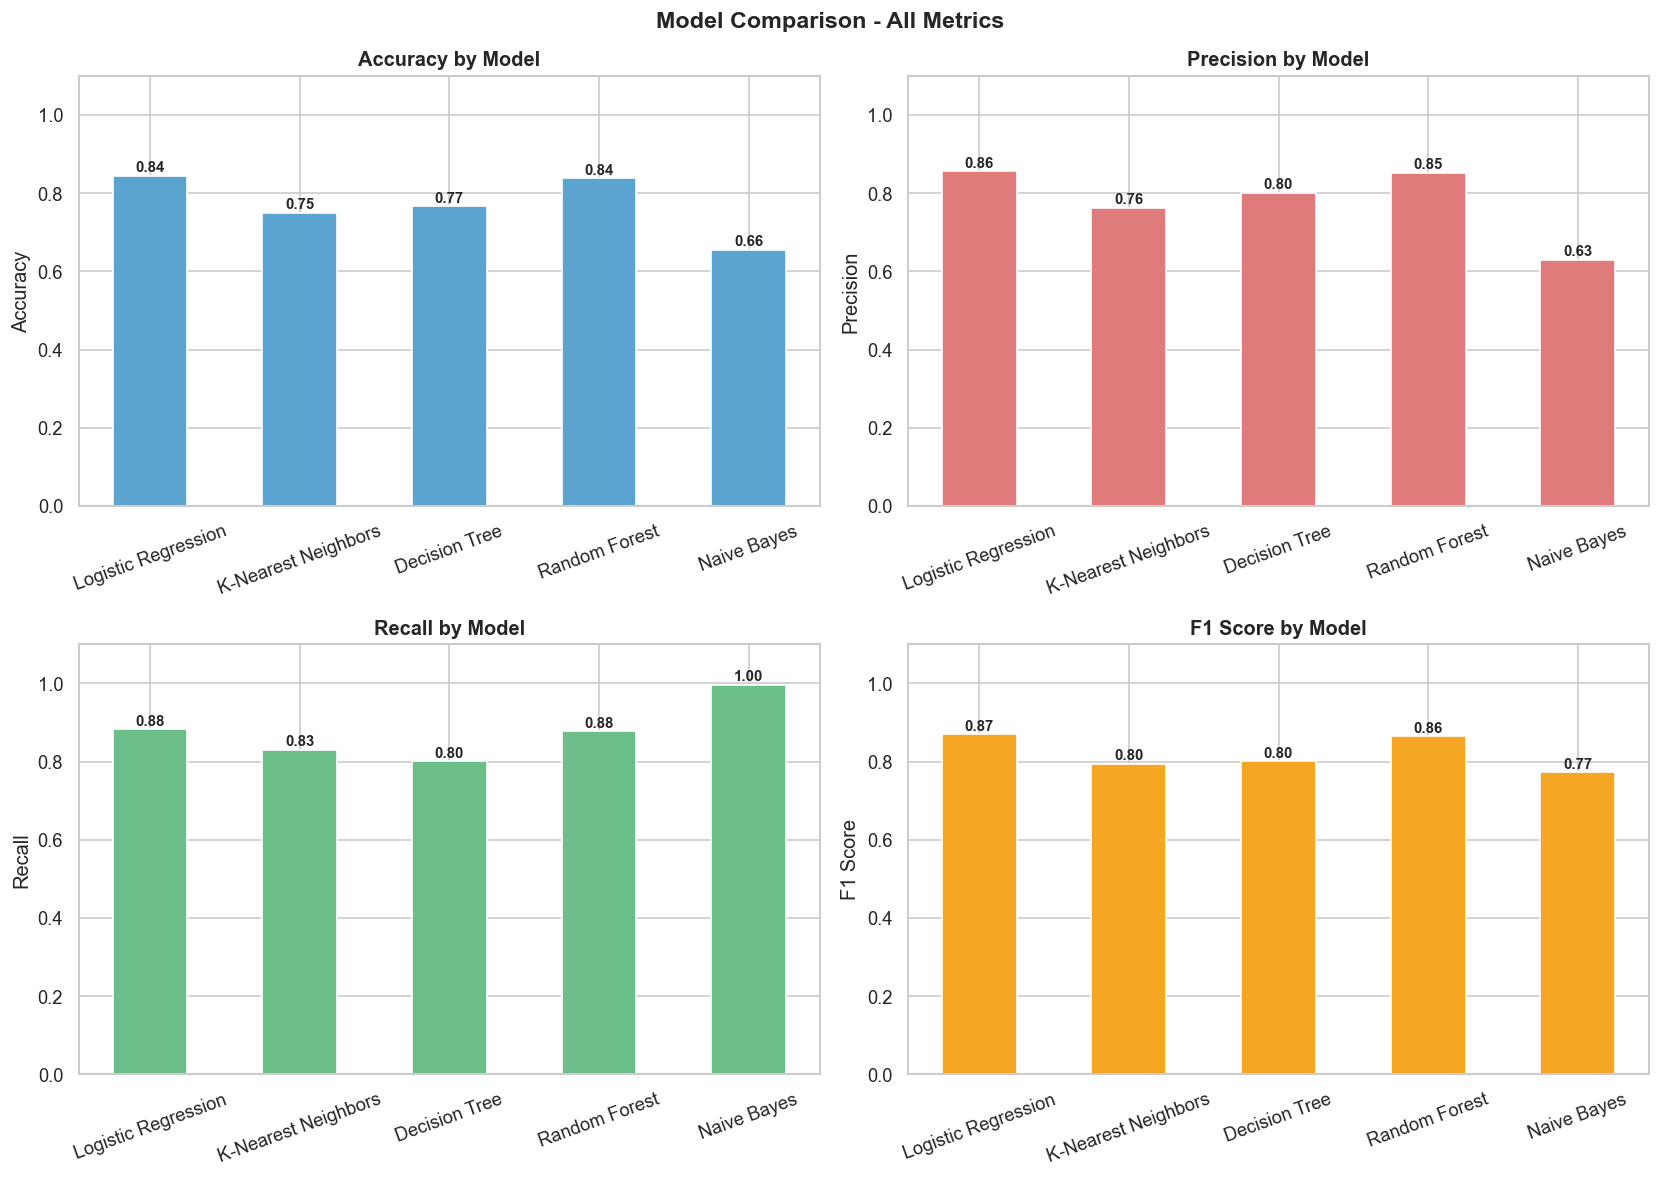

In [8]:
# Bar chart comparing all four metrics across models
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors  = ["#5BA4CF", "#E07B7B", "#6DBF8A", "#F5A623"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    values = results_df[metric] if metric != "Accuracy" else results_df[metric] / 100
    bars = axes[i].bar(results_df.index, values, color=colors[i], edgecolor="white", width=0.5)
    axes[i].set_title(f"{metric} by Model", fontweight="bold")
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1.1)
    axes[i].tick_params(axis="x", rotation=20)

    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Model Comparison - All Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison_metrics.png", bbox_inches="tight")
plt.show()


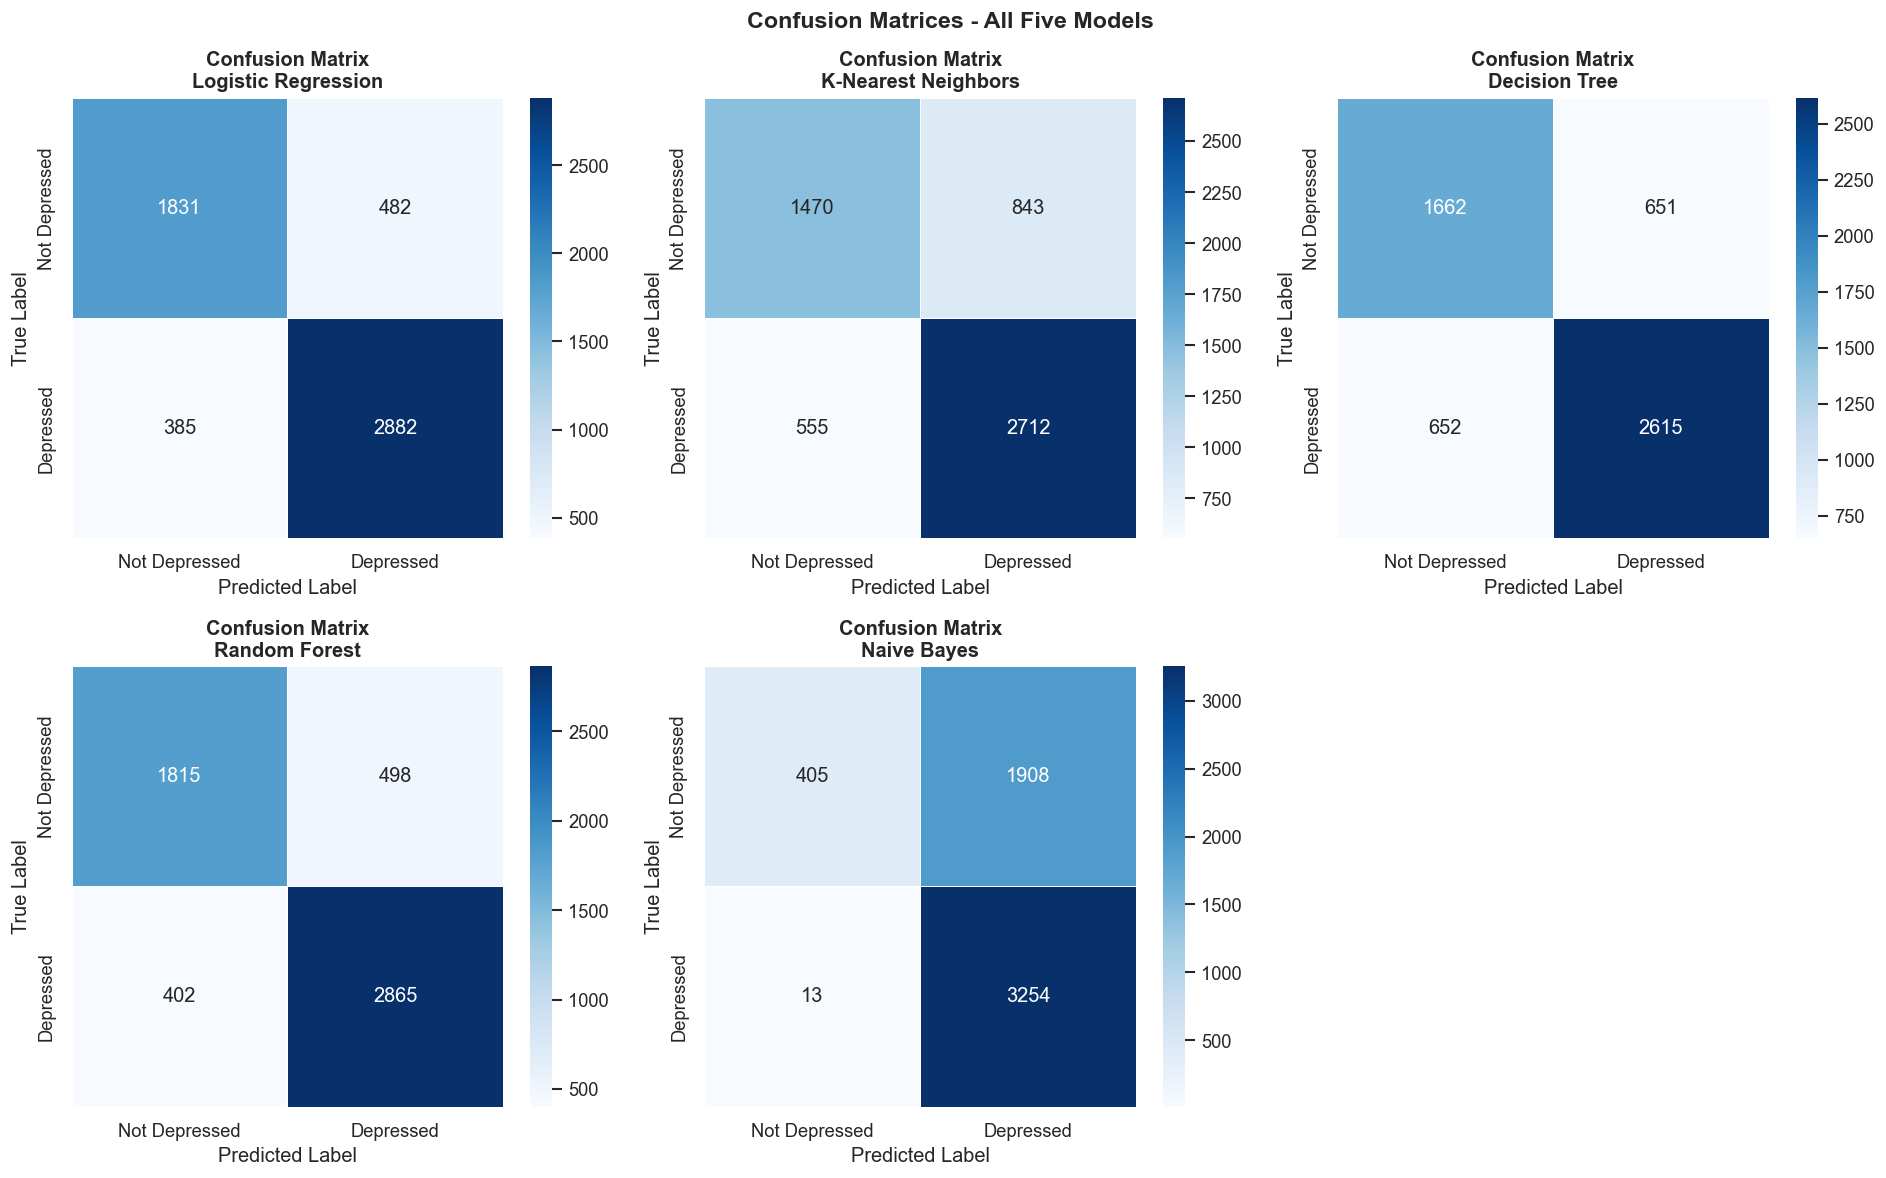

In [9]:
# Confusion matrices for all five models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

trained_models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors" : KNeighborsClassifier(n_neighbors=5),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes"         : GaussianNB(),
}

for i, (name, model) in enumerate(trained_models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Depressed", "Depressed"],
                yticklabels=["Not Depressed", "Depressed"],
                ax=axes[i], linewidths=0.5)
    axes[i].set_title(f"Confusion Matrix\n{name}", fontweight="bold")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle("Confusion Matrices - All Five Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices_all_models.png", bbox_inches="tight")
plt.show()


## 6. Justification and Reflection

### Which models would I carry forward for tuning?

I would carry forward **Logistic Regression** and **Random Forest** for tuning.

Looking at the results table, Logistic Regression had the highest accuracy at 84.48% and the highest F1 score at 0.8694, making it the most balanced and reliable model overall. Random Forest came in second with an accuracy of 83.87% and an F1 score of 0.8643, which is very close and still strong across all metrics.

Both models outperformed K-Nearest Neighbors, Decision Tree, and Naive Bayes in terms of balanced performance. While Naive Bayes had the highest recall at 0.9960, its accuracy of only 65.57% means it incorrectly classifies too many non-depressed students as depressed, making it unreliable for practical use.

Logistic Regression and Random Forest strike the best balance between catching actual depressed students and avoiding false alarms, which is why I chose them for the tuning stage.

---

### Reflection: A model with the highest accuracy is not always the best model.

In my Student Depression Dataset, Naive Bayes had the highest recall at 0.9960, meaning it almost never missed a depressed student. However, its accuracy was only 65.57%, which is the lowest among all five models. This means it was incorrectly flagging too many non-depressed students as depressed.

If I only looked at accuracy, I would pick Logistic Regression at 84.48% and potentially overlook that Naive Bayes catches almost every real case of depression. In a mental health setting, missing a depressed student (false negative) can be more harmful than a false alarm (false positive). So depending on the goal, the best model is not always the one with the highest accuracy. I need to look at all the metrics together, especially recall and F1 score, before making a final decision.
